# Q10.
```{admonition}
:class: note
This exercise focuses on the brain tumor data.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from lifelines import KaplanMeierFitter, CoxPHFitter

In [4]:
import seaborn as sns

In [ ]:
brain = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/BrainCancer.csv',usecols=range(1,9))

In [6]:
brain.head(3)

,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,Female,Meningioma,Infratentorial,90,6.11,SRS,0,57.64
1,Male,HG glioma,Supratentorial,90,19.35,SRT,1,8.98
2,Female,Meningioma,Infratentorial,70,7.95,SRS,0,26.46


## (a)
```{admonition}
:class: note
Plot the Kaplan-Meier survival curve with ±1 standard error bands, using the `KaplanMeierFitter()` estimator in the `lifelines` package.

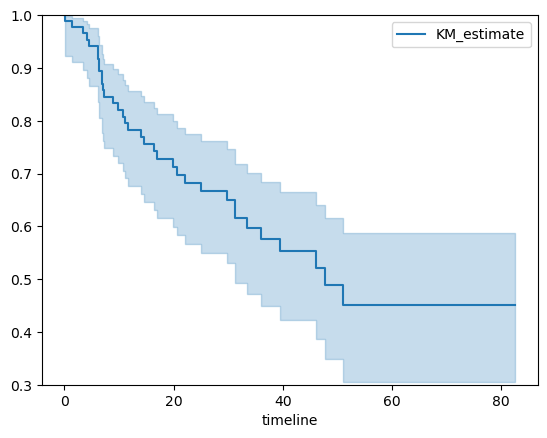

In [7]:
km = KaplanMeierFitter()
km_brain = km.fit(brain['time'],brain['status'])
km_brain.plot()
plt.ylim(0.3,1)
plt.show()

## (b)
```{admonition}
:class: note
Draw a bootstrap sample of size $n = 88$ from the pairs $(y_{i}, \delta_{i})$, and compute the resulting Kaplan-Meier survival curve. Repeat this process $B = 200$ times. Use the results to obtain an estimate of the standard error of the Kaplan-Meier survival curve at each timepoint. Compare this to the standard errors obtained in (a).

In [8]:
rng = np.random.default_rng(1728)

times = brain['time'].unique()
times.sort()
kmf = KaplanMeierFitter()
boot = np.zeros((len(times),200))

for B in range(200):
    idx = rng.choice(88,88)
    y_b = brain['time'].iloc[idx]
    d_b = brain['status'].iloc[idx]
    kmf_bootstrap = kmf.fit(y_b,d_b)

    boot[:,B] = kmf_bootstrap.survival_function_at_times(times).values
boot_se = boot.std(axis=1,ddof=1)

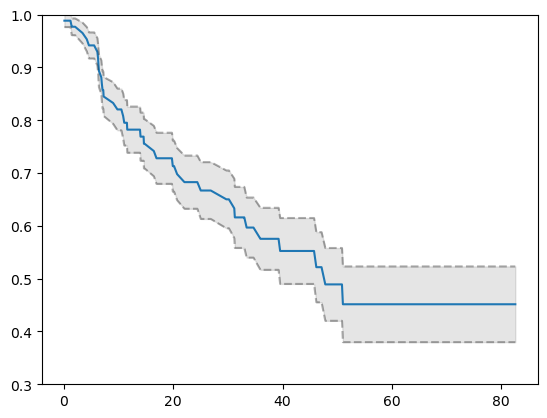

In [9]:
surv_curve = km_brain.survival_function_at_times(times)
pos_se = surv_curve+boot_se
neg_se = surv_curve-boot_se
plt.plot(times,surv_curve)
plt.plot(times,pos_se,'k--',alpha=0.3)
plt.plot(times,neg_se,'k--',alpha=0.3)
plt.fill_between(times,neg_se,pos_se,alpha=0.1,color='k')
plt.ylim(0.3,1)
plt.show()

## (c)
```{admonition}
:class: note
Fit a Cox proportional hazards model that uses all of the predictors to predict survival. Summarize the main findings.

In [10]:
brain_onehot = pd.get_dummies(brain,columns=['sex','diagnosis','loc','stereo'],drop_first=True).dropna()

In [11]:
cph = CoxPHFitter()
cph.fit(df=brain_onehot,duration_col='time',event_col='status')
cph.summary[['coef','se(coef)','p']]

,coef,se(coef),p
covariate,,,
ki,-0.057920,0.018313,0.001563
gtv,0.036041,0.022623,0.111125
sex_Male,0.097854,0.360701,0.786169
diagnosis_LG glioma,-1.091266,0.573943,0.057256
diagnosis_Meningioma,-2.082012,0.453688,0.000004
diagnosis_Other,-1.235849,0.625866,0.048311
loc_Supratentorial,0.375835,0.697787,0.590156
stereo_SRT,0.139636,0.598031,0.815379


## (d)
```{admonition}
:class: note
Stratify the data by the value of `ki`. (Since only one observation has `ki==40`, you can group that observation together with the observations that have `ki==60`.) Plot Kaplan-Meier survival curves for each of the five strata, adjusted for the other predictors.

In [12]:
levels = [60,70,80,90,100]

cat_cols = brain.select_dtypes(include='str').columns
num_cols = brain.select_dtypes(exclude='str').columns

baseline = pd.concat([brain[cat_cols].mode(),
    brain[num_cols].mean().to_frame().T],axis=1)

baseline = pd.concat([baseline,brain]).reset_index(drop=True)
baseline = pd.get_dummies(baseline,columns=['sex','diagnosis','loc','stereo'],drop_first=True)
baseline = baseline.iloc[0].to_frame().T

brain_strat = baseline.iloc[[0]*5]
brain_strat['ki'] = levels
brain_strat.index = levels

In [13]:
pred_surv = cph.predict_survival_function(brain_strat)
pred_surv.index.name = 'time'
pred_surv_plot = pred_surv.reset_index().melt(id_vars='time',var_name='ki',value_name='survival probability')

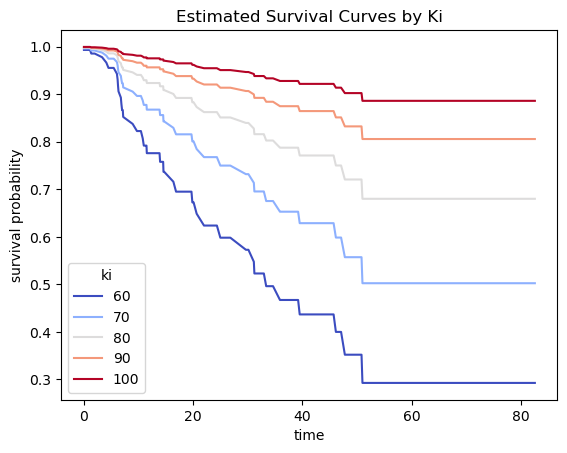

In [14]:
sns.lineplot(pred_surv_plot,x='time',y='survival probability',hue='ki',palette='coolwarm')
plt.title('Estimated Survival Curves by Ki')
plt.show()